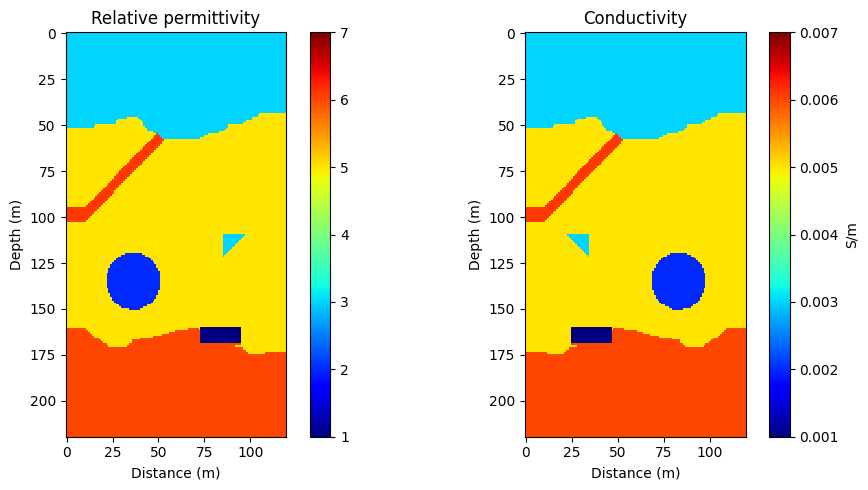

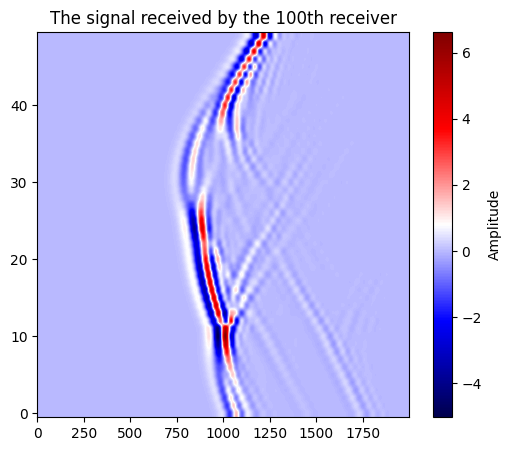

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import DeepGPR
import matplotlib.pyplot as plt
from skimage import filters
import time

# Set up the parameters and models
device=torch.device("cuda")
dx=0.05
dt=5e-11
nt=2000

source_location=torch.zeros((50,1,3),device=device,dtype=torch.int)
source_location[:,0,0]=torch.arange(10, 210, 4)
source_location[:,:,1]=10

receiver_location=torch.zeros((50,200,3),device=device,dtype=torch.int)
receiver_location[:,:,0]=torch.arange(10, 210, 1).repeat(50,1)
receiver_location[:,:,1]=110


freq=2e8
peak_time = 1 / freq
source_amplitudes = torch.zeros((1,nt,1),device=device)
source_amplitudes[0,:,0]=DeepGPR.ricker(freq, nt, dt, peak_time).to(device)


ert = F.pad(torch.tensor(np.load('2DFWImodel.npy')).unsqueeze(0).unsqueeze(0), pad=(10, 10, 10, 10), mode='replicate').squeeze()
set = ert.clone()*0.001
set[105:, :] = torch.flip(set[105:, :], dims=[1])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  
im1 = axes[0].imshow(ert.cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=7,vmin=1)
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(set.cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=0.007,vmin=0.001)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('Conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()


#Forward modeling
r_obs = DeepGPR.compute(
    device=device, dx=dx, dt=dt, 
    source_amplitudes=source_amplitudes,
    source_location=source_location, 
    receiver_location=receiver_location, 
    er=ert, se=set,model_gradient_sampling_interval=10
)

plt.figure(figsize=(6, 5)) 
im = plt.imshow(r_obs[-1][:,:,100].detach().cpu().numpy(), cmap='seismic', origin='lower',aspect='auto')
plt.colorbar(im, label='Amplitude') 
plt.title("The signal received by the 100th receiver") 
plt.show()


In [2]:
er=torch.tensor(filters.gaussian(ert,sigma=20),device=device)
se=torch.tensor(filters.gaussian(set,sigma=20),device=device)


optimiser_phase1 = torch.optim.Adam([
    {'params': er, 'lr': 0.2},
])

optimiser_phase2 = torch.optim.Adam([
    {'params': er, 'lr': 0.1},
    {'params': se, 'lr': 0.0001}
])
phase1_epochs = 50 
losses = []
n_epochs=201

loss_fnmse = torch.nn.MSELoss()
loss_fnl1= torch.nn.L1Loss()

start_time = time.time()


tv_criterion = DeepGPR.TVRegularization(weight_ep=20,weight_sigma=0.0000000001).to(device)

Epoch 0, Total Loss: 1612276.47 (Data: 1601686.75), Epoch Time: 1.59s, Total Time: 1.61s


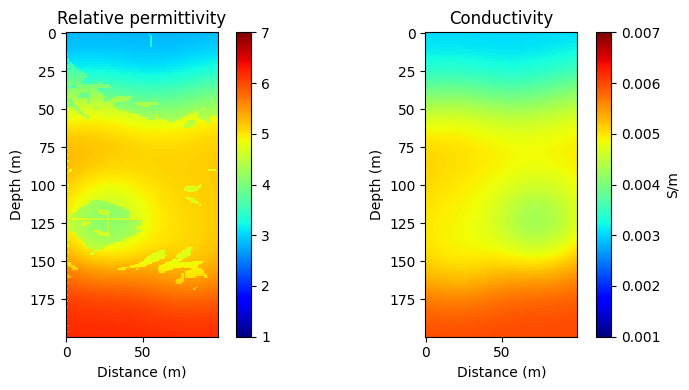

Epoch 1, Total Loss: 1301439.76 (Data: 1275185.50), Epoch Time: 1.65s, Total Time: 3.53s
Epoch 2, Total Loss: 1223791.67 (Data: 1186539.50), Epoch Time: 1.54s, Total Time: 5.07s
Epoch 3, Total Loss: 1166690.93 (Data: 1120120.50), Epoch Time: 1.56s, Total Time: 6.63s
Epoch 4, Total Loss: 1116634.23 (Data: 1062279.75), Epoch Time: 1.56s, Total Time: 8.20s
Epoch 5, Total Loss: 995661.85 (Data: 934430.19), Epoch Time: 1.58s, Total Time: 9.77s
Epoch 6, Total Loss: 940812.43 (Data: 873944.31), Epoch Time: 1.56s, Total Time: 11.33s
Epoch 7, Total Loss: 887549.12 (Data: 817033.81), Epoch Time: 1.57s, Total Time: 12.90s
Epoch 8, Total Loss: 836924.03 (Data: 762846.94), Epoch Time: 1.58s, Total Time: 14.48s
Epoch 9, Total Loss: 785066.16 (Data: 707552.12), Epoch Time: 1.59s, Total Time: 16.07s
Epoch 10, Total Loss: 698789.46 (Data: 618132.31), Epoch Time: 1.58s, Total Time: 17.65s
Epoch 11, Total Loss: 685150.71 (Data: 600878.94), Epoch Time: 1.58s, Total Time: 19.23s
Epoch 12, Total Loss: 68144

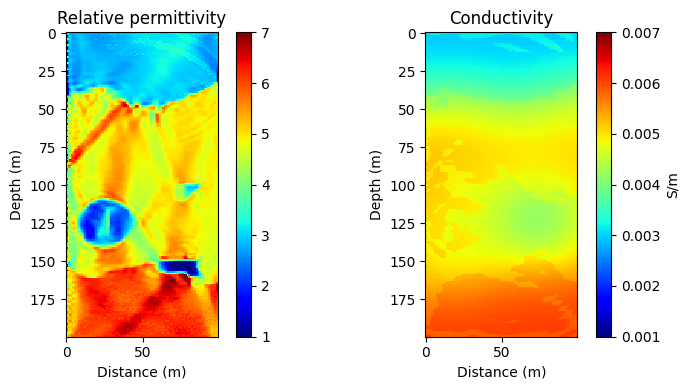

Epoch 51, Total Loss: 834479.37 (Data: 730320.81), Epoch Time: 1.58s, Total Time: 82.40s
Epoch 52, Total Loss: 595468.54 (Data: 494799.72), Epoch Time: 1.59s, Total Time: 83.99s
Epoch 53, Total Loss: 338445.66 (Data: 241899.12), Epoch Time: 1.59s, Total Time: 85.58s
Epoch 54, Total Loss: 549303.37 (Data: 452846.50), Epoch Time: 1.57s, Total Time: 87.15s
Epoch 55, Total Loss: 554033.37 (Data: 461219.69), Epoch Time: 1.57s, Total Time: 88.72s
Epoch 56, Total Loss: 405402.17 (Data: 316445.81), Epoch Time: 1.55s, Total Time: 90.28s
Epoch 57, Total Loss: 309756.08 (Data: 223090.25), Epoch Time: 1.59s, Total Time: 91.87s
Epoch 58, Total Loss: 406944.44 (Data: 320017.06), Epoch Time: 1.55s, Total Time: 93.41s
Epoch 59, Total Loss: 403920.48 (Data: 318060.16), Epoch Time: 1.54s, Total Time: 94.96s
Epoch 60, Total Loss: 296705.62 (Data: 212861.16), Epoch Time: 1.55s, Total Time: 96.51s
Epoch 61, Total Loss: 264172.62 (Data: 181979.52), Epoch Time: 1.56s, Total Time: 98.07s
Epoch 62, Total Loss:

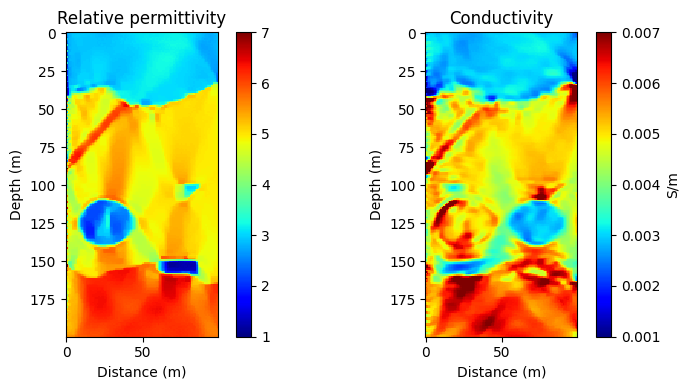

Epoch 101, Total Loss: 135572.20 (Data: 76865.79), Epoch Time: 1.60s, Total Time: 161.21s
Epoch 102, Total Loss: 140290.22 (Data: 81713.30), Epoch Time: 1.58s, Total Time: 162.79s
Epoch 103, Total Loss: 130541.70 (Data: 72527.02), Epoch Time: 1.58s, Total Time: 164.36s
Epoch 104, Total Loss: 133228.32 (Data: 75448.54), Epoch Time: 1.58s, Total Time: 165.94s
Epoch 105, Total Loss: 128941.23 (Data: 71547.12), Epoch Time: 1.56s, Total Time: 167.51s
Epoch 106, Total Loss: 125794.03 (Data: 68720.19), Epoch Time: 1.56s, Total Time: 169.07s
Epoch 107, Total Loss: 135955.57 (Data: 79206.30), Epoch Time: 1.56s, Total Time: 170.63s
Epoch 108, Total Loss: 124413.94 (Data: 68047.95), Epoch Time: 1.59s, Total Time: 172.22s
Epoch 109, Total Loss: 140689.82 (Data: 84535.04), Epoch Time: 1.57s, Total Time: 173.79s
Epoch 110, Total Loss: 128745.41 (Data: 73004.40), Epoch Time: 1.58s, Total Time: 175.37s
Epoch 111, Total Loss: 139702.55 (Data: 84223.42), Epoch Time: 1.58s, Total Time: 176.95s
Epoch 112,

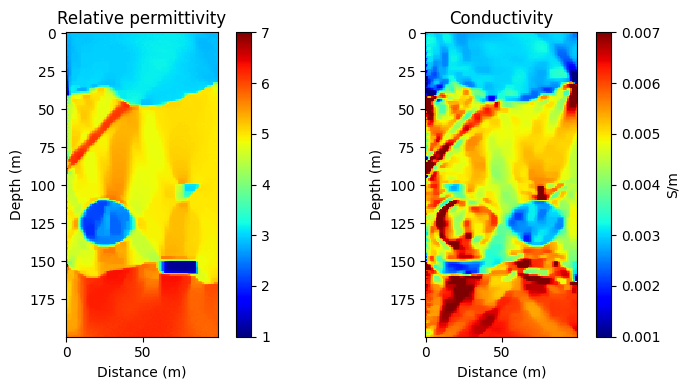

Epoch 151, Total Loss: 123180.98 (Data: 76792.35), Epoch Time: 1.59s, Total Time: 240.02s
Epoch 152, Total Loss: 116122.18 (Data: 69871.16), Epoch Time: 1.58s, Total Time: 241.60s
Epoch 153, Total Loss: 122254.55 (Data: 76132.67), Epoch Time: 1.61s, Total Time: 243.20s
Epoch 154, Total Loss: 114381.11 (Data: 68481.05), Epoch Time: 1.59s, Total Time: 244.79s
Epoch 155, Total Loss: 124639.61 (Data: 78849.34), Epoch Time: 1.58s, Total Time: 246.37s
Epoch 156, Total Loss: 118119.64 (Data: 72456.93), Epoch Time: 1.58s, Total Time: 247.96s
Epoch 157, Total Loss: 119527.99 (Data: 73923.11), Epoch Time: 1.56s, Total Time: 249.52s
Epoch 158, Total Loss: 114975.22 (Data: 69509.91), Epoch Time: 1.56s, Total Time: 251.08s
Epoch 159, Total Loss: 119746.81 (Data: 74393.73), Epoch Time: 1.55s, Total Time: 252.63s
Epoch 160, Total Loss: 113371.02 (Data: 68146.83), Epoch Time: 1.56s, Total Time: 254.19s
Epoch 161, Total Loss: 119240.85 (Data: 74089.39), Epoch Time: 1.55s, Total Time: 255.74s
Epoch 162,

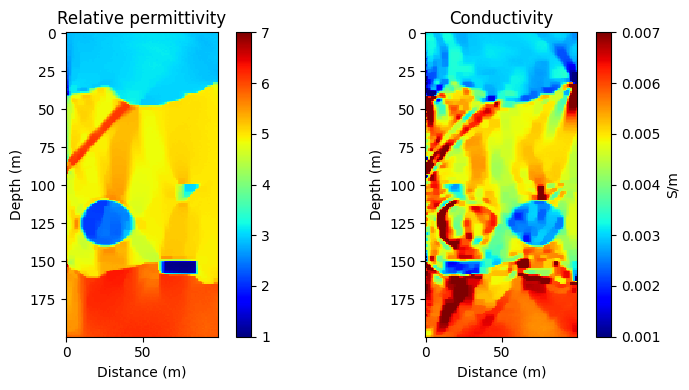

In [3]:

tv_ratio = 0.1 

for epoch in range(n_epochs):
    if epoch < phase1_epochs:
        current_optimizer = optimiser_phase1
        se.requires_grad = False 
        er.requires_grad = True  
    else:
        current_optimizer = optimiser_phase2
        se.requires_grad = True    
        er.requires_grad = True   
    
    epoch_start = time.time()
    
    current_optimizer.zero_grad()

    r = DeepGPR.compute(
        device=device, dx=dx, dt=dt, 
        source_amplitudes=source_amplitudes,
        source_location=source_location, 
        receiver_location=receiver_location, 
        er=er, se=se
    )
  
    loss_data = loss_fnl1(r[-1], r_obs[-1]) * 1e7
    loss_data.backward()

    if er.requires_grad:
        er.grad[:, :10] = 0
        er.grad[:, -10:] = 0
        grad_data_er = er.grad.clone() 
        norm_data_er = torch.norm(grad_data_er) + 1e-8 
        
    if se.requires_grad:
        se.grad[:, :10] = 0
        se.grad[:, -10:] = 0
        grad_data_se = se.grad.clone() 
        norm_data_se = torch.norm(grad_data_se) + 1e-8

    current_optimizer.zero_grad()  
    
    loss_tv = tv_criterion(er, se)
    loss_tv.backward()  

    if er.requires_grad:
        er.grad[:, :10] = 0
        er.grad[:, -10:] = 0
        norm_tv_er = torch.norm(er.grad) + 1e-8
        weight_tv_er = (norm_data_er / norm_tv_er) * tv_ratio
        er.grad = grad_data_er + er.grad * weight_tv_er

    if se.requires_grad:
        se.grad[:, :10] = 0
        se.grad[:, -10:] = 0
        norm_tv_se = torch.norm(se.grad) + 1e-8
        weight_tv_se = (norm_data_se / norm_tv_se) * tv_ratio
        se.grad = grad_data_se + se.grad * weight_tv_se

    current_optimizer.step()
    total_loss = loss_data.item() + loss_tv.item()
    losses.append(total_loss) 
    
    epoch_time = time.time() - epoch_start  
    total_time = time.time() - start_time  
    
    with torch.no_grad():
        se.data.clamp_(min=0)
        er.data.clamp_(min=1)
        
    print(f"Epoch {epoch}, Total Loss: {total_loss:.2f} (Data: {loss_data.item():.2f}), Epoch Time: {epoch_time:.2f}s, Total Time: {total_time:.2f}s")
    
    if epoch % 50 == 0:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
        im1 = axes[0].imshow(er[10:-10,10:-10].detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=7,vmin=1)
        cbar1 = plt.colorbar(im1, ax=axes[0])
        axes[0].set_title('Relative permittivity')
        axes[0].set_xlabel('Distance (m)')
        axes[0].set_ylabel('Depth (m)')

        im2 = axes[1].imshow(se[10:-10,10:-10].detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=0.007,vmin=0.001)
        cbar2 = plt.colorbar(im2, ax=axes[1])
        cbar2.set_label('S/m')
        axes[1].set_title('Conductivity')
        axes[1].set_xlabel('Distance (m)')
        axes[1].set_ylabel('Depth (m)')

        plt.tight_layout()
        plt.show()